In [10]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [11]:
iris = load_iris()

In [15]:
X = iris.data
y = iris.target

In [16]:
X.shape

(150, 4)

<Axes: >

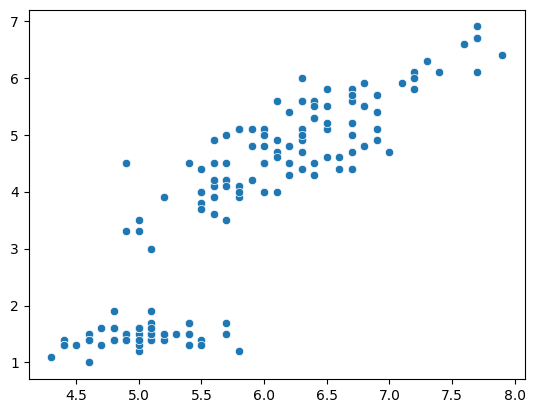

In [18]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,2])

In [19]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# PCA - dimentionality reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # convert total dimentions to 2

pca_data = pca.fit_transform(X_scaled)

In [42]:
# Elbow Method
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)
    

<Axes: >

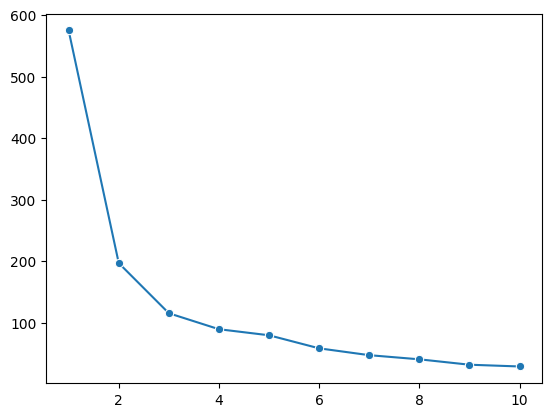

In [43]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

In [44]:
from kneed import KneeLocator   

knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing") 
print("optimal K:", knee.elbow)

optimal K: 3


<Axes: >

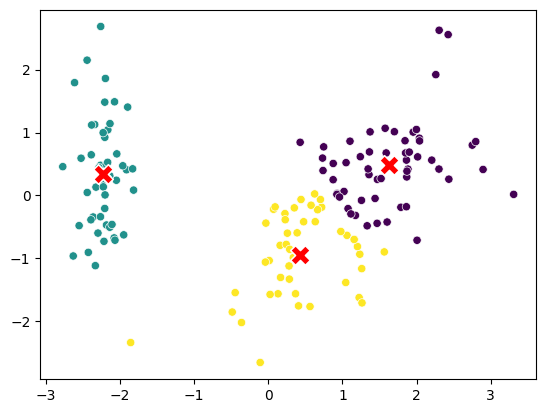

In [53]:
# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], c=labels)

# plot the centroids
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker='X', c="red", s=200) 